In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, ConcatDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

In [2]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
# Set SEED for reproducibility

SEED = 24520152

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Train directory path

TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [5]:
# Save directory path

SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [6]:
# 3 labels: Glioma Tumor, Meningioma Tumor, Pituitary Tumor

CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [7]:
# Model name

MODEL_NAME = 'DenseNet121'
MODEL_NAME

'DenseNet121'

In [8]:
# Hyperparameters

BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3
DROPOUT_RATE = 0.3

In [9]:
def get_data_for_fold(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE) -> tuple[DataLoader, DataLoader]:
    """
    Creates PyTorch DataLoaders for K-Fold Cross-Validation, specifically tailored
    for DenseNet121 transfer learning with ImageNet standards.

    This function sets up a data pipeline that:
    1. Applies standard ImageNet normalization statistics.
    2. Implements strong data augmentation for the training set (using torchvision v2).
    3. Prepares validation data with deterministic preprocessing (Resize -> CenterCrop).
    4. Handles subset selection based on the current fold index 'k'.

    Args:
        k (int): The index of the validation fold (e.g., 1 to 5). 
                 The folder 'Subset_{k}' will be used for validation, while 
                 all other subsets are concatenated for training.
        train_dir (str): Path to the root directory containing the fold subsets 
                         (e.g., 'Subset_1', 'Subset_2', etc.).
        batch_size (int, optional): Number of samples per batch. Defaults to 32.

    Returns:
        tuple: A tuple containing:
            - train_loader (DataLoader): The training data loader (shuffled).
            - val_loader (DataLoader): The validation data loader (not shuffled).
    """

    # Standard ImageNet normalization statistics
    norm_mean=[0.485, 0.456, 0.406]
    norm_std=[0.229, 0.224, 0.225]

    # Training Transform Pipeline
    train_transform = v2.Compose([
        # Resize to 256x256 first. This provides a buffer for subsequent 
        # rotation/translation and cropping, preventing black border artifacts.
        v2.Resize(size=256),

        # Apply Data Augmentation
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),

        # Use CenterCrop to focus on the primary subject
        v2.CenterCrop(size=224),

        # Convert PIL/Numpy to Tensor, cast to Float32, and rescale to [0, 1]
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),

        # Normalize using ImageNet mean and std
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # Validation Transform Pipeline
    val_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])

    # Data Path Setup
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]

    # Worker Configuration
    # Determine the optimal number of CPU workers to prevent bottlenecks.
    # Capped at 4 to avoid excessive memory overhead.
    num_workers = min(4, os.cpu_count())

    # Validation Loader
    val_dataset = ImageFolder(root=val_dir, transform=val_transform)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    # Training Loader
    list_train_dataset = [ImageFolder(root=td, transform=train_transform) for td in train_dirs]
    train_dataset = ConcatDataset(datasets=list_train_dataset)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader

In [10]:
class DenseNet121(nn.Module):
    """
    DenseNet121-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: DenseNet121 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = 3, dropout_rate: float = 0.3) -> None:
        super().__init__()

        # Load Pre-trained DenseNet121
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        backbone = models.densenet121(weights=weights)

        # DenseNet121 .features contains all Conv/Relu/MaxPool layers
        self.features = backbone.features

        # Freezing parameters to prevent updating during training
        for param in self.features.parameters():
            param.requires_grad = False

        # Define Custom Classifier Head.
        self.in_features = 1024 
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 1024, H, W) -> (Batch, 1024, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 1024, 1, 1) -> (Batch, 1024)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=self.in_features, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W).
                              Expected standard ImageNet normalization.

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """
        
        # Feature extraction (Frozen)
        x = self.features(x)
        # The torchvision.models.densenet121 `.features` block ends with a 
        # BatchNorm layer (norm5), which outputs both negative and positive values.
        # We MUST apply ReLU here to zero out negative values (noise/background).
        x = F.relu(x, inplace=True)
        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)
        
        # Output Logits
        logits = self.classifier(x)
        
        return logits

In [11]:
def build_densenet121(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> DenseNet121:
    """
    Factory function to instantiate the customized DenseNet121 model for Transfer Learning.

    This function initializes a `DenseNet121` which includes:
    1. A frozen DenseNet121 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (ReLU -> Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        DenseNet121: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """
    
    model = DenseNet121(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [12]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [13]:
def train_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-4, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Trains the DenseNet121 classifier using a custom training loop with Early Stopping 
    and Learning Rate Reduction.

    This function handles the training and validation phases, logs metrics, 
    and saves the best model weights based on validation accuracy.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The current K-Fold index (used for naming the saved file).
        save_dir (str, optional): Directory to save the model checkpoints. 
            Defaults to global SAVE_DIR.
        batch_size (int, optional): Batch size for training. 
            Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. 
            Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. 
            Defaults to 1e-4.
        model_name (str, optional): Name prefix for the saved model file. 
            Defaults to global MODEL_NAME.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history:
            - 'loss': List of training losses per epoch.
            - 'accuracy': List of training accuracies per epoch.
            - 'val_loss': List of validation losses per epoch.
            - 'val_accuracy': List of validation accuracies per epoch.
    """

    # 1. Initialize Model & Move to Device
    model = build_densenet121().to(device=device)

    # Summary
    print(f"\nFold: {fold_k} - Block 6")
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1))
    
    # 2. Setup Optimizer, Loss Function, and Scheduler
    optimizer = Adam(params=model.parameters(), lr=learning_rate)

    # Custom Focal Loss to handle potential class imbalance
    criterion = SparseCategoricalFocalLoss()

    # Reduce learning rate if validation loss stops improving
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    # 3. Initialize Tracking Variables
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    # Early Stopping Configuration
    early_stop_patience = 6
    early_stop_counter = 0

    # Define the path where the best model weights will be saved
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.pth')

    # START TRAINING LOOP
    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        # Create a progress bar for the current epoch
        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            # Move data to the same device as the model
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # 1. Clear previous gradients
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
    
            # 3. Backward pass (Compute gradients)
            loss.backward()

            # 4. Update weights
            optimizer.step()

            # 5. Accumulate Metrics
            # Multiply by batch size to get the total loss for the batch (denormalize mean)
            train_loss += loss.item() * inputs.size(0)

            # Calculate accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            # Update progress bar description
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Calculate average metrics for the entire epoch
        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Disable gradient calculation to save memory and computation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Accumulate validation metrics
                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        # LOGGING & HISTORY
        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        # CALLBACKS
        # 1. Update Learning Rate Scheduler (monitors validation loss)
        scheduler.step(metrics=epoch_val_loss)

        # 2. Model Checkpoint (Save Best Model)
        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            # 3. Early Stopping Logic
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    # Restore the best model weights before returning
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [14]:
def test_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the full training and evaluation pipeline for a specific K-Fold.

    This function performs the following steps:
    1. Trains the model using `train_classifier`.
    2. Loads the best model weights saved during that training session.
    3. Evaluates the loaded model on the validation set.
    4. Generates a performance summary, classification report, and confusion matrix plot.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The index of the current fold (used for file naming and titles).
        class_names (list[str], optional): List of class names for reporting and plotting. 
            Defaults to global CLASS_NAMES.
        save_dir (str, optional): Directory to save and load model checkpoints. 
            Defaults to global SAVE_DIR.
        model_name (str, optional): Name prefix for the model. 
            Defaults to global MODEL_NAME.

    Returns:
        float: The final accuracy score on the validation set using the best model weights.
    """

    # 1. Train the model
    # This will run the training loop and save the best weights to disk
    history = train_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k)

    # 2. Prepare to load the best model
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.pth')

    # Initialize the model architecture and move it to the configured device
    model = build_densenet121().to(device=device)
    # Load the best weights saved during training
    # map_location: Ensures weights are loaded to the correct device (avoids GPU/CPU mismatch)
    # weights_only=True: Security best practice to prevent loading arbitrary code
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    # 3. Setup Evaluation
    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Initialize lists to aggregate predictions and true labels for Scikit-Learn metrics
    y_true_list = []
    y_pred_list = []

    # 4. Inference Loop
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate Batch Loss (multiply by batch size to denormalize)
            val_loss += loss.item() * inputs.size(0)

            # Calculate Batch Accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            # Store predictions for reporting
            # .cpu(): Move tensor from GPU to CPU
            # .numpy(): Convert tensor to numpy array
            # .extend(): Flatten the batch and add to the main list
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    # 5. Calculate Final Average Metrics
    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    # 6. Report Results
    # Create a Summary DataFrame
    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    # Print detailed Classification Report (Precision, Recall, F1-Score)
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 7. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block 6)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [15]:
def set_trainable_from_block(model: nn.Module, block_num: int) -> None:
    """
    Configures the trainability of DenseNet121 layers for fine-tuning.

    This function freezes all layers in the backbone (features) up to the specified
    `block_num`, and unfreezes all layers from that block onwards. 
    The custom classifier head is always set to be trainable.

    Mapping of DenseNet121 Feature Indices:
    - Block 5: Unfreeze DenseBlock 4 
    - Block 4: Unfreeze DenseBlock 3 
    - Block 3: Unfreeze DenseBlock 2 
    - Block 2: Unfreeze DenseBlock 1 
    - Block 1: Unfreeze Everything (Including Stem: Conv0, Norm0...).
    Args:
        model (nn.Module): The DenseNet121 model instance.
        block_num (int): The block number (1 to 5) from which to start training.
            - 5: Train only the last Dense Block (DenseBlock 4) and classifier.
            - 4: Train from DenseBlock 3 onwards.
            - 3: Train from DenseBlock 2 onwards.
            - 2: Train from DenseBlock 1 onwards (skipping Stem).
            - 1: Train the entire network.
    """

    # Map the abstract "Block Number" to the actual starting layer index in model.features
    block_indices = {
        5: 10, 
        4: 8,  
        3: 6, 
        2: 4,  
        1: 0,  
    }


    start_index = block_indices[block_num]

    # 1. Configure Backbone
    for i, child in enumerate(model.features.children()):
        if i >= start_index:
            for param in child.parameters():
                param.requires_grad = True
        else:
            for param in child.parameters():
                param.requires_grad = False

    # 2. Configure Classifier Head 
    for param in model.classifier.parameters():
        param.requires_grad = True

In [16]:
def train_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-5, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Fine-tunes a specific block of the DenseNet121 model (Progressive Fine-Tuning).

    Process:
    1. Identifies the checkpoint from the previous training stage (block + 1).
    2. Loads those weights into the model.
    3. Unfreezes layers starting from the current `block` downwards.
    4. Trains the model with a lower learning rate to adapt features.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Fold index.
        block (int): The DenseNet block number to unfreeze (4, 3, 2, 1).
        save_dir (str, optional): Directory for checkpoints.
        batch_size (int, optional): Batch size.
        epochs (int, optional): Max epochs.
        learning_rate (float, optional): Learning rate (1e-5 recommended for fine-tuning).
        model_name (str, optional): Model naming prefix. Defaults to 'DenseNet121'.

    Returns:
        dict[str, list[float]]: Training history dictionary.
    """

    # 1. Setup paths for previous and current checkpoints
    prev_block = block + 1
    prev_checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{prev_block}_fold_{fold_k}.pth')
    
    # Path to save the current training result
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    # 2. Initialize Model & Load Previous Weights
    model = build_densenet121().to(device=device) 
    model.load_state_dict(state_dict=torch.load(f=prev_checkpoint_path, map_location=device, weights_only=True))
    
    # 3. Unfreeze specific layers
    set_trainable_from_block(model=model, block_num=block)

    # Summary
    print(f"\nFold: {fold_k} - Block {block}")
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1))
    
    
    # 4. Setup Training Components
    optimizer = Adam(params=model.parameters(), lr=learning_rate)
    criterion = SparseCategoricalFocalLoss() # Class Loss của bạn
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    # 5. Training Loop Initialization
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    
    # Deep copy initial weights to ensure we have a fallback
    best_model_weights = copy.deepcopy(model.state_dict()) 

    early_stop_patience = 6
    early_stop_counter = 0

    # 6. Main Loop
    for epoch in range(epochs):
        model.train()
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            optimizer.zero_grad()
            
            # Forward pass (Logits)
            outputs = model(inputs) 
            # Loss calculation
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            # Metric calculation
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        # Validation Phase
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        # Scheduler Step
        scheduler.step(metrics=epoch_val_loss)

        # Checkpointing & Early Stopping
        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights...')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'Early stopping triggered. Restoring best weights.')
                break
    
    # Restore best weights before returning
    model.load_state_dict(state_dict=best_model_weights)
    
    return history

In [17]:
def test_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the fine-tuning and evaluation pipeline for a specific DenseNet block.

    Process:
    1. Triggers `train_block` to fine-tune the model from the specified `block`.
    2. Loads the best weights saved during that fine-tuning session.
    3. Evaluates metrics (Loss/Accuracy).
    4. Generates Classification Report and Confusion Matrix.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Current Fold index.
        block (int): The specific block number being fine-tuned (4, 3, 2, 1).
        class_names (list[str], optional): Class labels for plotting. Defaults to CLASS_NAMES.
        save_dir (str, optional): Save directory. Defaults to SAVE_DIR.
        model_name (str, optional): Model prefix. Defaults to MODEL_NAME.

    Returns:
        float: Final validation accuracy.
    """

    # 1. Run Fine-Tuning for the specific block
    history = train_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block, model_name=model_name)

    # 2. Path to the best weights for THIS block
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    # 3. Initialize Model & Load Weights
    model = build_densenet121().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    # 4. Evaluation Loop
    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    # 5. Reporting
    results = [{
        'Model': f'{model_name} (Block {block})',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print("\nEvaluation Results:")
    print(results_df)

    print("\nClassification Report:")
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block {block})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

Fold: 1 block 6
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 167MB/s] 



Fold: 1 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     (6,953,856)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 3,075
Non-trainable params: 6,953,856
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward pass size (MB): 577

Epoch 1/50 | loss: 0.5332 - accuracy: 0.4401 | val_loss: 0.4043 - val_accuracy: 0.5664
val_accuracy improved from 0.0000 to 0.5664, saving weights to /kaggle/working/DenseNet121_block_6_fold_1.pth


Epoch 2/50 | loss: 0.4130 - accuracy: 0.5559 | val_loss: 0.3509 - val_accuracy: 0.6107
val_accuracy improved from 0.5664 to 0.6107, saving weights to /kaggle/working/DenseNet121_block_6_fold_1.pth


...

Epoch 13/50 | loss: 0.1998 - accuracy: 0.7942 | val_loss: 0.1688 - val_accuracy: 0.8266
val_accuracy did not improve from 0.8432


Epoch 14/50 | loss: 0.1948 - accuracy: 0.7958 | val_loss: 0.1734 - val_accuracy: 0.8063
val_accuracy did not improve from 0.8432


Epoch 15/50 | loss: 0.1796 - accuracy: 0.8033 | val_loss: 0.1614 - val_accuracy: 0.8321
val_accuracy did not improve from 0.8432


Epoch 16/50 | loss: 0.1884 - accuracy: 0.7887 | val_loss: 0.1643 - val_accuracy: 0.8155
val_accuracy did not improve from 0.8432


Epoch 17/50 | loss: 0.1836 - accuracy: 0.7982 | val_loss: 0.1741 - val_accuracy: 0.7952
val_accuracy did not improve from 0.8432
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  DenseNet121  0.169495  0.843173
                  precision    recall  f1-score   support

    Glioma Tumor       0.80      0.96      0.87       245
Meningioma Tumor       0.78      0.47      0.59       112
 Pituitary Tumor       0.94      0.91      0.93       185

        accuracy                           0.84       542
       macro avg       0.84      0.78      0.80       542
    weighted avg       0.84      0.84      0.83       542



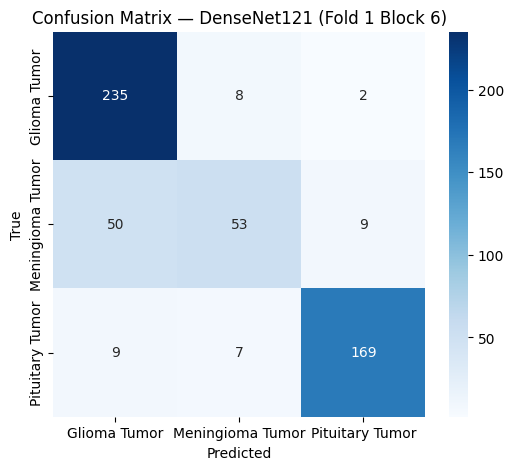

Fold: 1 block 5

Fold: 1 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 2,163,203
Non-trainable params: 4,793,728
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.1874 - accuracy: 0.8029 | val_loss: 0.1608 - val_accuracy: 0.8026
val_accuracy improved from 0.0000 to 0.8026, saving weights...


Epoch 2/50 | loss: 0.1653 - accuracy: 0.8279 | val_loss: 0.1442 - val_accuracy: 0.8284
val_accuracy improved from 0.8026 to 0.8284, saving weights...


Epoch 3/50 | loss: 0.1499 - accuracy: 0.8335 | val_loss: 0.1284 - val_accuracy: 0.8764
val_accuracy improved from 0.8284 to 0.8764, saving weights...


Epoch 4/50 | loss: 0.1330 - accuracy: 0.8497 | val_loss: 0.1157 - val_accuracy: 0.8801
val_accuracy improved from 0.8764 to 0.8801, saving weights...


...

Epoch 14/50 | loss: 0.0881 - accuracy: 0.8941 | val_loss: 0.0967 - val_accuracy: 0.8985
val_accuracy did not improve from 0.9004


Epoch 15/50 | loss: 0.0847 - accuracy: 0.8989 | val_loss: 0.1024 - val_accuracy: 0.8819
val_accuracy did not improve from 0.9004


Epoch 16/50 | loss: 0.0822 - accuracy: 0.9013 | val_loss: 0.0970 - val_accuracy: 0.8985
val_accuracy did not improve from 0.9004


Epoch 17/50 | loss: 0.0764 - accuracy: 0.9072 | val_loss: 0.0960 - val_accuracy: 0.8985
val_accuracy did not improve from 0.9004


Epoch 18/50 | loss: 0.0884 - accuracy: 0.8929 | val_loss: 0.0929 - val_accuracy: 0.9004
val_accuracy did not improve from 0.9004
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 5)  0.090371  0.900369

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.95      0.95       245
Meningioma Tumor       0.72      0.91      0.81       112
 Pituitary Tumor       1.00      0.83      0.91       185

        accuracy                           0.90       542
       macro avg       0.89      0.90      0.89       542
    weighted avg       0.92      0.90      0.90       542



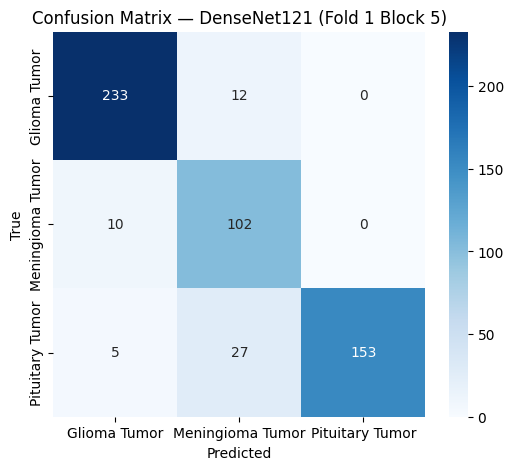

Fold: 1 block 4

Fold: 1 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 5,527,299
Non-trainable params: 1,429,632
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0877 - accuracy: 0.8993 | val_loss: 0.0767 - val_accuracy: 0.9151
val_accuracy improved from 0.0000 to 0.9151, saving weights...


Epoch 2/50 | loss: 0.0806 - accuracy: 0.8989 | val_loss: 0.0893 - val_accuracy: 0.8893
val_accuracy did not improve from 0.9151


Epoch 3/50 | loss: 0.0717 - accuracy: 0.9140 | val_loss: 0.1086 - val_accuracy: 0.8893
val_accuracy did not improve from 0.9151


Epoch 4/50 | loss: 0.0593 - accuracy: 0.9227 | val_loss: 0.0857 - val_accuracy: 0.9059
val_accuracy did not improve from 0.9151


...

Epoch 11/50 | loss: 0.0303 - accuracy: 0.9611 | val_loss: 0.0422 - val_accuracy: 0.9483
val_accuracy did not improve from 0.9576


Epoch 12/50 | loss: 0.0302 - accuracy: 0.9607 | val_loss: 0.0412 - val_accuracy: 0.9446
val_accuracy did not improve from 0.9576


Epoch 13/50 | loss: 0.0257 - accuracy: 0.9699 | val_loss: 0.0394 - val_accuracy: 0.9446
val_accuracy did not improve from 0.9576


Epoch 14/50 | loss: 0.0224 - accuracy: 0.9730 | val_loss: 0.0412 - val_accuracy: 0.9483
val_accuracy did not improve from 0.9576


Epoch 15/50 | loss: 0.0229 - accuracy: 0.9683 | val_loss: 0.0370 - val_accuracy: 0.9539
val_accuracy did not improve from 0.9576
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 4)  0.041068  0.957565

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      1.00      0.97       245
Meningioma Tumor       0.91      0.92      0.92       112
 Pituitary Tumor       1.00      0.93      0.96       185

        accuracy                           0.96       542
       macro avg       0.95      0.95      0.95       542
    weighted avg       0.96      0.96      0.96       542



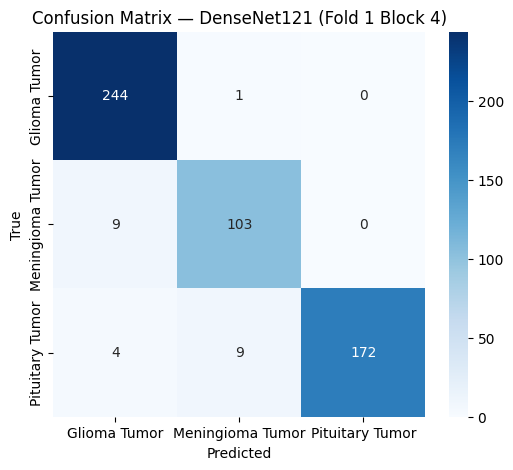

Fold: 1 block 3

Fold: 1 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,579,075
Non-trainable params: 377,856
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward

Epoch 1/50 | loss: 0.0379 - accuracy: 0.9477 | val_loss: 0.0767 - val_accuracy: 0.9336
val_accuracy improved from 0.0000 to 0.9336, saving weights...


Epoch 2/50 | loss: 0.0339 - accuracy: 0.9588 | val_loss: 0.0469 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9336


Epoch 3/50 | loss: 0.0326 - accuracy: 0.9584 | val_loss: 0.0774 - val_accuracy: 0.9280
val_accuracy did not improve from 0.9336


Epoch 4/50 | loss: 0.0257 - accuracy: 0.9679 | val_loss: 0.0294 - val_accuracy: 0.9576
val_accuracy improved from 0.9336 to 0.9576, saving weights...


...

Epoch 10/50 | loss: 0.0119 - accuracy: 0.9873 | val_loss: 0.0769 - val_accuracy: 0.9280
val_accuracy did not improve from 0.9613


Epoch 11/50 | loss: 0.0136 - accuracy: 0.9806 | val_loss: 0.0516 - val_accuracy: 0.9465
val_accuracy did not improve from 0.9613


Epoch 12/50 | loss: 0.0098 - accuracy: 0.9877 | val_loss: 0.0361 - val_accuracy: 0.9520
val_accuracy did not improve from 0.9613


Epoch 13/50 | loss: 0.0073 - accuracy: 0.9917 | val_loss: 0.0307 - val_accuracy: 0.9520
val_accuracy did not improve from 0.9613


Epoch 14/50 | loss: 0.0071 - accuracy: 0.9913 | val_loss: 0.0302 - val_accuracy: 0.9502
val_accuracy did not improve from 0.9613
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 3)  0.031529  0.961255

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.99      0.98       245
Meningioma Tumor       0.88      0.96      0.92       112
 Pituitary Tumor       0.99      0.92      0.96       185

        accuracy                           0.96       542
       macro avg       0.95      0.96      0.95       542
    weighted avg       0.96      0.96      0.96       542



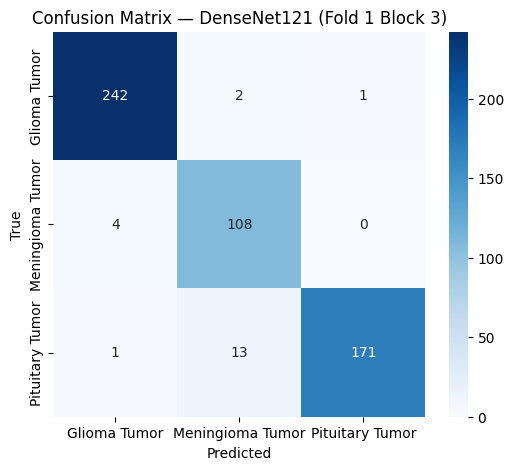

Fold: 1 block 2

Fold: 1 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,947,395
Non-trainable params: 9,536
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0242 - accuracy: 0.9730 | val_loss: 0.0446 - val_accuracy: 0.9483
val_accuracy improved from 0.0000 to 0.9483, saving weights...


Epoch 2/50 | loss: 0.0170 - accuracy: 0.9806 | val_loss: 0.0517 - val_accuracy: 0.9373
val_accuracy did not improve from 0.9483


Epoch 3/50 | loss: 0.0161 - accuracy: 0.9833 | val_loss: 0.1011 - val_accuracy: 0.8985
val_accuracy did not improve from 0.9483


Epoch 4/50 | loss: 0.0165 - accuracy: 0.9818 | val_loss: 0.0535 - val_accuracy: 0.9502
val_accuracy improved from 0.9483 to 0.9502, saving weights...


...

Epoch 11/50 | loss: 0.0089 - accuracy: 0.9897 | val_loss: 0.0336 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9760


Epoch 12/50 | loss: 0.0079 - accuracy: 0.9909 | val_loss: 0.0219 - val_accuracy: 0.9649
val_accuracy did not improve from 0.9760


Epoch 13/50 | loss: 0.0075 - accuracy: 0.9901 | val_loss: 0.0382 - val_accuracy: 0.9594
val_accuracy did not improve from 0.9760


Epoch 14/50 | loss: 0.0046 - accuracy: 0.9929 | val_loss: 0.0167 - val_accuracy: 0.9705
val_accuracy did not improve from 0.9760


Epoch 15/50 | loss: 0.0034 - accuracy: 0.9960 | val_loss: 0.0224 - val_accuracy: 0.9668
val_accuracy did not improve from 0.9760
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 2)  0.019812  0.976015

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.96      0.98       245
Meningioma Tumor       0.92      0.97      0.95       112
 Pituitary Tumor       0.99      1.00      0.99       185

        accuracy                           0.98       542
       macro avg       0.97      0.98      0.97       542
    weighted avg       0.98      0.98      0.98       542



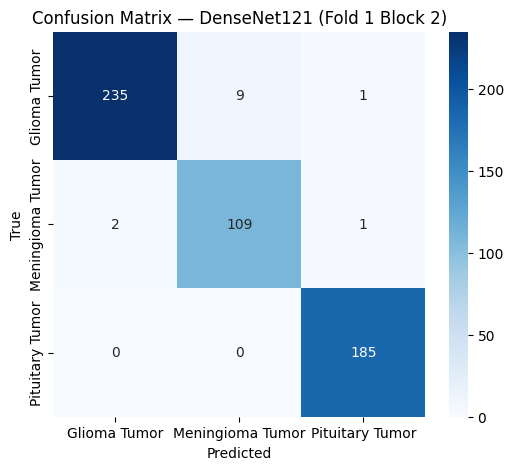

Fold: 1 block 1

Fold: 1 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,956,931
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward pass size (

Epoch 1/50 | loss: 0.0149 - accuracy: 0.9790 | val_loss: 0.0335 - val_accuracy: 0.9539
val_accuracy improved from 0.0000 to 0.9539, saving weights...


Epoch 2/50 | loss: 0.0113 - accuracy: 0.9857 | val_loss: 0.0265 - val_accuracy: 0.9613
val_accuracy improved from 0.9539 to 0.9613, saving weights...


Epoch 3/50 | loss: 0.0042 - accuracy: 0.9956 | val_loss: 0.0805 - val_accuracy: 0.9170
val_accuracy did not improve from 0.9613


Epoch 4/50 | loss: 0.0158 - accuracy: 0.9822 | val_loss: 0.0214 - val_accuracy: 0.9723
val_accuracy improved from 0.9613 to 0.9723, saving weights...


...

Epoch 7/50 | loss: 0.0048 - accuracy: 0.9941 | val_loss: 0.0393 - val_accuracy: 0.9428
val_accuracy did not improve from 0.9742


Epoch 8/50 | loss: 0.0071 - accuracy: 0.9901 | val_loss: 0.0681 - val_accuracy: 0.9244
val_accuracy did not improve from 0.9742


Epoch 9/50 | loss: 0.0054 - accuracy: 0.9948 | val_loss: 0.0200 - val_accuracy: 0.9705
val_accuracy did not improve from 0.9742


Epoch 10/50 | loss: 0.0031 - accuracy: 0.9972 | val_loss: 0.0276 - val_accuracy: 0.9576
val_accuracy did not improve from 0.9742


Epoch 11/50 | loss: 0.0029 - accuracy: 0.9960 | val_loss: 0.0294 - val_accuracy: 0.9594
val_accuracy did not improve from 0.9742
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 1)  0.021978   0.97417

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.98      0.98       245
Meningioma Tumor       0.90      0.98      0.94       112
 Pituitary Tumor       1.00      0.97      0.98       185

        accuracy                           0.97       542
       macro avg       0.96      0.98      0.97       542
    weighted avg       0.98      0.97      0.97       542



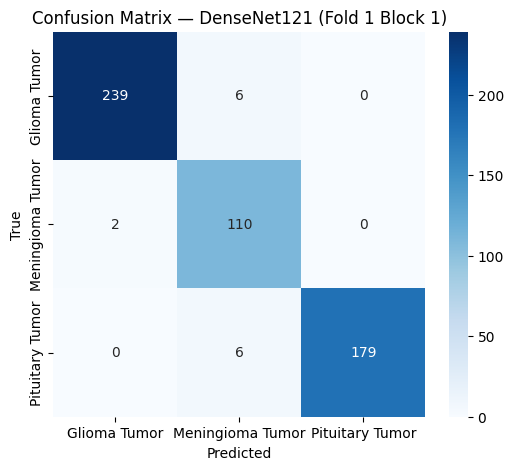

Fold: 2 block 6

Fold: 2 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     (6,953,856)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 3,075
Non-trainable params: 6,953,856
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward pas

Epoch 1/50 | loss: 0.5651 - accuracy: 0.4080 | val_loss: 0.4092 - val_accuracy: 0.5596
val_accuracy improved from 0.0000 to 0.5596, saving weights to /kaggle/working/DenseNet121_block_6_fold_2.pth


Epoch 2/50 | loss: 0.4376 - accuracy: 0.5266 | val_loss: 0.3441 - val_accuracy: 0.6613
val_accuracy improved from 0.5596 to 0.6613, saving weights to /kaggle/working/DenseNet121_block_6_fold_2.pth


Epoch 3/50 | loss: 0.3620 - accuracy: 0.6113 | val_loss: 0.3074 - val_accuracy: 0.6760
val_accuracy improved from 0.6613 to 0.6760, saving weights to /kaggle/working/DenseNet121_block_6_fold_2.pth


Epoch 4/50 | loss: 0.3213 - accuracy: 0.6730 | val_loss: 0.2873 - val_accuracy: 0.7054
val_accuracy improved from 0.6760 to 0.7054, saving weights to /kaggle/working/DenseNet121_block_6_fold_2.pth


...

Epoch 33/50 | loss: 0.1494 - accuracy: 0.8369 | val_loss: 0.1632 - val_accuracy: 0.8056
val_accuracy did not improve from 0.8130


Epoch 34/50 | loss: 0.1508 - accuracy: 0.8356 | val_loss: 0.1623 - val_accuracy: 0.7938
val_accuracy did not improve from 0.8130


Epoch 35/50 | loss: 0.1471 - accuracy: 0.8415 | val_loss: 0.1608 - val_accuracy: 0.8041
val_accuracy did not improve from 0.8130


Epoch 36/50 | loss: 0.1456 - accuracy: 0.8428 | val_loss: 0.1626 - val_accuracy: 0.8056
val_accuracy did not improve from 0.8130


Epoch 37/50 | loss: 0.1503 - accuracy: 0.8398 | val_loss: 0.1619 - val_accuracy: 0.8056
val_accuracy did not improve from 0.8130
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  DenseNet121  0.162953   0.81296
                  precision    recall  f1-score   support

    Glioma Tumor       0.79      0.93      0.86       338
Meningioma Tumor       0.71      0.48      0.57       167
 Pituitary Tumor       0.93      0.90      0.91       174

        accuracy                           0.81       679
       macro avg       0.81      0.77      0.78       679
    weighted avg       0.81      0.81      0.80       679



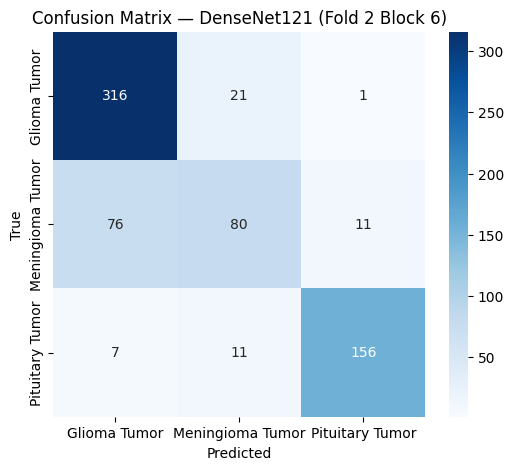

Fold: 2 block 5

Fold: 2 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 2,163,203
Non-trainable params: 4,793,728
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.1417 - accuracy: 0.8457 | val_loss: 0.1464 - val_accuracy: 0.8203
val_accuracy improved from 0.0000 to 0.8203, saving weights...


Epoch 2/50 | loss: 0.1364 - accuracy: 0.8549 | val_loss: 0.1503 - val_accuracy: 0.8159
val_accuracy did not improve from 0.8203


Epoch 3/50 | loss: 0.1208 - accuracy: 0.8646 | val_loss: 0.1308 - val_accuracy: 0.8277
val_accuracy improved from 0.8203 to 0.8277, saving weights...


Epoch 4/50 | loss: 0.1174 - accuracy: 0.8734 | val_loss: 0.1434 - val_accuracy: 0.8203
val_accuracy did not improve from 0.8277


...

Epoch 19/50 | loss: 0.0887 - accuracy: 0.8931 | val_loss: 0.1271 - val_accuracy: 0.8395
val_accuracy did not improve from 0.8483


Epoch 20/50 | loss: 0.0814 - accuracy: 0.9027 | val_loss: 0.1226 - val_accuracy: 0.8424
val_accuracy did not improve from 0.8483


Epoch 21/50 | loss: 0.0833 - accuracy: 0.9057 | val_loss: 0.1221 - val_accuracy: 0.8454
val_accuracy did not improve from 0.8483


Epoch 22/50 | loss: 0.0809 - accuracy: 0.9061 | val_loss: 0.1217 - val_accuracy: 0.8439
val_accuracy did not improve from 0.8483


Epoch 23/50 | loss: 0.0797 - accuracy: 0.9057 | val_loss: 0.1220 - val_accuracy: 0.8409
val_accuracy did not improve from 0.8483
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 5)  0.119328  0.848306

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.86      0.92      0.89       338
Meningioma Tumor       0.72      0.69      0.71       167
 Pituitary Tumor       0.96      0.86      0.90       174

        accuracy                           0.85       679
       macro avg       0.85      0.82      0.83       679
    weighted avg       0.85      0.85      0.85       679



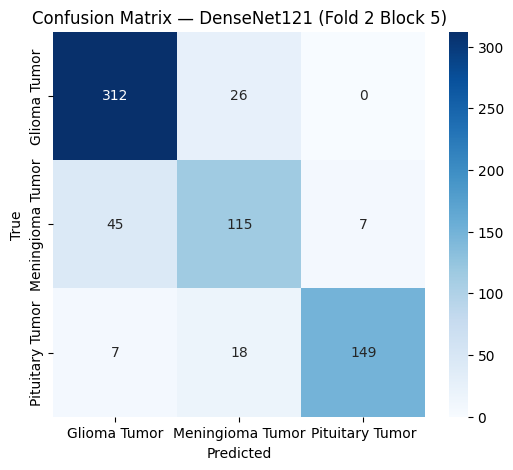

Fold: 2 block 4

Fold: 2 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 5,527,299
Non-trainable params: 1,429,632
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0977 - accuracy: 0.8918 | val_loss: 0.1229 - val_accuracy: 0.8454
val_accuracy improved from 0.0000 to 0.8454, saving weights...


Epoch 2/50 | loss: 0.0729 - accuracy: 0.9149 | val_loss: 0.0987 - val_accuracy: 0.8689
val_accuracy improved from 0.8454 to 0.8689, saving weights...


Epoch 3/50 | loss: 0.0642 - accuracy: 0.9237 | val_loss: 0.0994 - val_accuracy: 0.8807
val_accuracy improved from 0.8689 to 0.8807, saving weights...


Epoch 4/50 | loss: 0.0594 - accuracy: 0.9321 | val_loss: 0.0811 - val_accuracy: 0.8940
val_accuracy improved from 0.8807 to 0.8940, saving weights...


...

Epoch 18/50 | loss: 0.0211 - accuracy: 0.9723 | val_loss: 0.0699 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9293


Epoch 19/50 | loss: 0.0181 - accuracy: 0.9757 | val_loss: 0.0859 - val_accuracy: 0.9116
val_accuracy did not improve from 0.9293


Epoch 20/50 | loss: 0.0172 - accuracy: 0.9824 | val_loss: 0.0674 - val_accuracy: 0.9205
val_accuracy did not improve from 0.9293


Epoch 21/50 | loss: 0.0137 - accuracy: 0.9841 | val_loss: 0.0697 - val_accuracy: 0.9190
val_accuracy did not improve from 0.9293


Epoch 22/50 | loss: 0.0105 - accuracy: 0.9874 | val_loss: 0.0709 - val_accuracy: 0.9205
val_accuracy did not improve from 0.9293
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 4)  0.062371  0.929308

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.96      0.95       338
Meningioma Tumor       0.88      0.88      0.88       167
 Pituitary Tumor       0.96      0.93      0.94       174

        accuracy                           0.93       679
       macro avg       0.93      0.92      0.92       679
    weighted avg       0.93      0.93      0.93       679



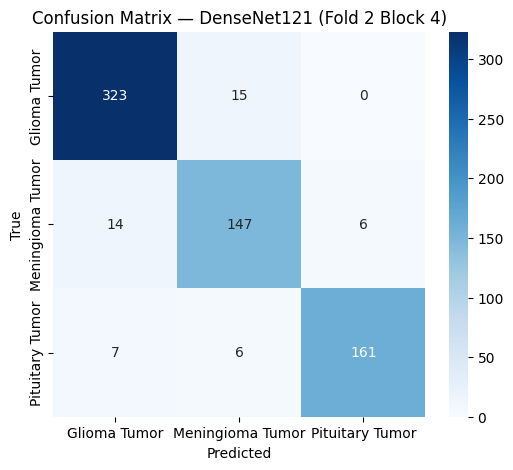

Fold: 2 block 3

Fold: 2 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,579,075
Non-trainable params: 377,856
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward

Epoch 1/50 | loss: 0.0237 - accuracy: 0.9694 | val_loss: 0.0625 - val_accuracy: 0.9234
val_accuracy improved from 0.0000 to 0.9234, saving weights...


Epoch 2/50 | loss: 0.0235 - accuracy: 0.9690 | val_loss: 0.0733 - val_accuracy: 0.9175
val_accuracy did not improve from 0.9234


Epoch 3/50 | loss: 0.0188 - accuracy: 0.9765 | val_loss: 0.0578 - val_accuracy: 0.9367
val_accuracy improved from 0.9234 to 0.9367, saving weights...


Epoch 4/50 | loss: 0.0200 - accuracy: 0.9715 | val_loss: 0.0725 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9367


...

Epoch 13/50 | loss: 0.0064 - accuracy: 0.9941 | val_loss: 0.0571 - val_accuracy: 0.9381
val_accuracy did not improve from 0.9396


Epoch 14/50 | loss: 0.0070 - accuracy: 0.9908 | val_loss: 0.0581 - val_accuracy: 0.9381
val_accuracy did not improve from 0.9396


Epoch 15/50 | loss: 0.0069 - accuracy: 0.9916 | val_loss: 0.0579 - val_accuracy: 0.9367
val_accuracy did not improve from 0.9396


Epoch 16/50 | loss: 0.0061 - accuracy: 0.9929 | val_loss: 0.0604 - val_accuracy: 0.9381
val_accuracy did not improve from 0.9396


Epoch 17/50 | loss: 0.0068 - accuracy: 0.9925 | val_loss: 0.0577 - val_accuracy: 0.9367
val_accuracy did not improve from 0.9396
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 3)  0.061228  0.939617

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.96      0.95       338
Meningioma Tumor       0.89      0.92      0.91       167
 Pituitary Tumor       0.99      0.91      0.95       174

        accuracy                           0.94       679
       macro avg       0.94      0.93      0.94       679
    weighted avg       0.94      0.94      0.94       679



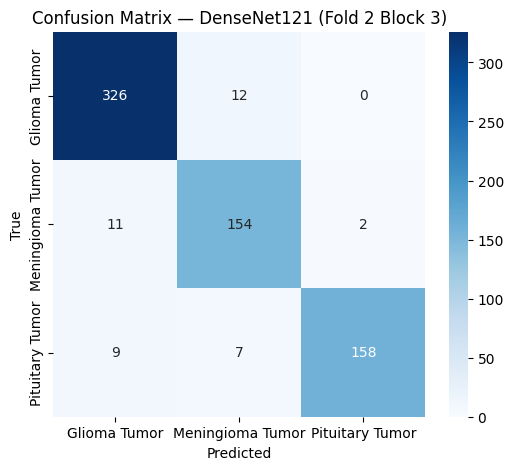

Fold: 2 block 2

Fold: 2 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,947,395
Non-trainable params: 9,536
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0174 - accuracy: 0.9803 | val_loss: 0.0604 - val_accuracy: 0.9278
val_accuracy improved from 0.0000 to 0.9278, saving weights...


Epoch 2/50 | loss: 0.0123 - accuracy: 0.9836 | val_loss: 0.0789 - val_accuracy: 0.9293
val_accuracy improved from 0.9278 to 0.9293, saving weights...


Epoch 3/50 | loss: 0.0089 - accuracy: 0.9891 | val_loss: 0.0489 - val_accuracy: 0.9455
val_accuracy improved from 0.9293 to 0.9455, saving weights...


Epoch 4/50 | loss: 0.0106 - accuracy: 0.9899 | val_loss: 0.1146 - val_accuracy: 0.9175
val_accuracy did not improve from 0.9455


...

Epoch 13/50 | loss: 0.0043 - accuracy: 0.9941 | val_loss: 0.0619 - val_accuracy: 0.9485
val_accuracy did not improve from 0.9514


Epoch 14/50 | loss: 0.0040 - accuracy: 0.9966 | val_loss: 0.0624 - val_accuracy: 0.9455
val_accuracy did not improve from 0.9514


Epoch 15/50 | loss: 0.0046 - accuracy: 0.9950 | val_loss: 0.0599 - val_accuracy: 0.9455
val_accuracy did not improve from 0.9514


Epoch 16/50 | loss: 0.0034 - accuracy: 0.9950 | val_loss: 0.0607 - val_accuracy: 0.9470
val_accuracy did not improve from 0.9514


Epoch 17/50 | loss: 0.0030 - accuracy: 0.9971 | val_loss: 0.0596 - val_accuracy: 0.9470
val_accuracy did not improve from 0.9514
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 2)  0.059173  0.951399

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.98      0.96       338
Meningioma Tumor       0.92      0.93      0.93       167
 Pituitary Tumor       0.99      0.93      0.96       174

        accuracy                           0.95       679
       macro avg       0.95      0.94      0.95       679
    weighted avg       0.95      0.95      0.95       679



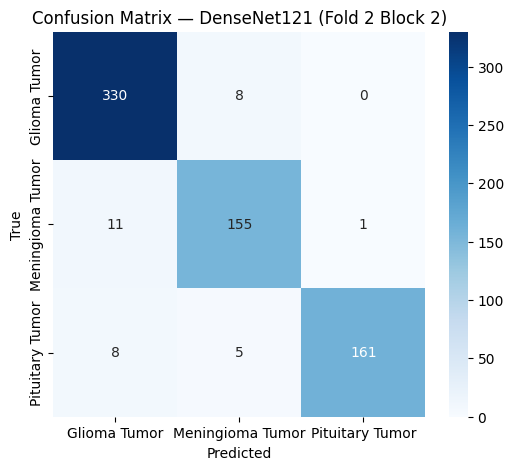

Fold: 2 block 1

Fold: 2 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,956,931
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward pass size (

Epoch 1/50 | loss: 0.0090 - accuracy: 0.9895 | val_loss: 0.1121 - val_accuracy: 0.9264
val_accuracy improved from 0.0000 to 0.9264, saving weights...


Epoch 2/50 | loss: 0.0181 - accuracy: 0.9782 | val_loss: 0.0736 - val_accuracy: 0.9308
val_accuracy improved from 0.9264 to 0.9308, saving weights...


Epoch 3/50 | loss: 0.0054 - accuracy: 0.9950 | val_loss: 0.0595 - val_accuracy: 0.9396
val_accuracy improved from 0.9308 to 0.9396, saving weights...


Epoch 4/50 | loss: 0.0058 - accuracy: 0.9933 | val_loss: 0.0775 - val_accuracy: 0.9234
val_accuracy did not improve from 0.9396


...

Epoch 15/50 | loss: 0.0017 - accuracy: 0.9987 | val_loss: 0.0669 - val_accuracy: 0.9426
val_accuracy did not improve from 0.9455


Epoch 16/50 | loss: 0.0024 - accuracy: 0.9975 | val_loss: 0.0692 - val_accuracy: 0.9455
val_accuracy did not improve from 0.9455


Epoch 17/50 | loss: 0.0023 - accuracy: 0.9975 | val_loss: 0.0688 - val_accuracy: 0.9440
val_accuracy did not improve from 0.9455


Epoch 18/50 | loss: 0.0027 - accuracy: 0.9966 | val_loss: 0.0689 - val_accuracy: 0.9440
val_accuracy did not improve from 0.9455


Epoch 19/50 | loss: 0.0016 - accuracy: 0.9987 | val_loss: 0.0683 - val_accuracy: 0.9440
val_accuracy did not improve from 0.9455
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 1)  0.071115  0.945508

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.97      0.95       338
Meningioma Tumor       0.92      0.93      0.93       167
 Pituitary Tumor       0.99      0.91      0.95       174

        accuracy                           0.95       679
       macro avg       0.95      0.94      0.94       679
    weighted avg       0.95      0.95      0.95       679



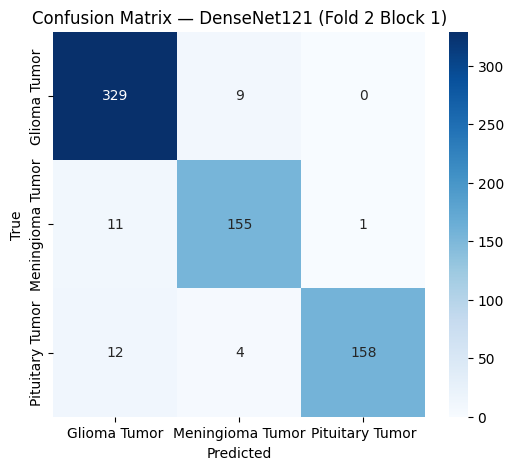

Fold: 3 block 6

Fold: 3 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     (6,953,856)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 3,075
Non-trainable params: 6,953,856
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward pas

Epoch 1/50 | loss: 0.4970 - accuracy: 0.4563 | val_loss: 0.3918 - val_accuracy: 0.5962
val_accuracy improved from 0.0000 to 0.5962, saving weights to /kaggle/working/DenseNet121_block_6_fold_3.pth


Epoch 2/50 | loss: 0.4003 - accuracy: 0.5522 | val_loss: 0.3307 - val_accuracy: 0.6836
val_accuracy improved from 0.5962 to 0.6836, saving weights to /kaggle/working/DenseNet121_block_6_fold_3.pth


Epoch 3/50 | loss: 0.3497 - accuracy: 0.6292 | val_loss: 0.2906 - val_accuracy: 0.7360
val_accuracy improved from 0.6836 to 0.7360, saving weights to /kaggle/working/DenseNet121_block_6_fold_3.pth


Epoch 4/50 | loss: 0.3127 - accuracy: 0.6593 | val_loss: 0.2747 - val_accuracy: 0.7413
val_accuracy improved from 0.7360 to 0.7413, saving weights to /kaggle/working/DenseNet121_block_6_fold_3.pth


...

Epoch 15/50 | loss: 0.1919 - accuracy: 0.7974 | val_loss: 0.1697 - val_accuracy: 0.8339
val_accuracy did not improve from 0.8497


Epoch 16/50 | loss: 0.1843 - accuracy: 0.8054 | val_loss: 0.1767 - val_accuracy: 0.8182
val_accuracy did not improve from 0.8497


Epoch 17/50 | loss: 0.1820 - accuracy: 0.8134 | val_loss: 0.1737 - val_accuracy: 0.8182
val_accuracy did not improve from 0.8497


Epoch 18/50 | loss: 0.1815 - accuracy: 0.8082 | val_loss: 0.1638 - val_accuracy: 0.8269
val_accuracy did not improve from 0.8497


Epoch 19/50 | loss: 0.1751 - accuracy: 0.8186 | val_loss: 0.1619 - val_accuracy: 0.8374
val_accuracy did not improve from 0.8497
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  DenseNet121  0.171805   0.84965
                  precision    recall  f1-score   support

    Glioma Tumor       0.84      0.88      0.86       231
Meningioma Tumor       0.72      0.67      0.69       139
 Pituitary Tumor       0.95      0.94      0.94       202

        accuracy                           0.85       572
       macro avg       0.84      0.83      0.83       572
    weighted avg       0.85      0.85      0.85       572



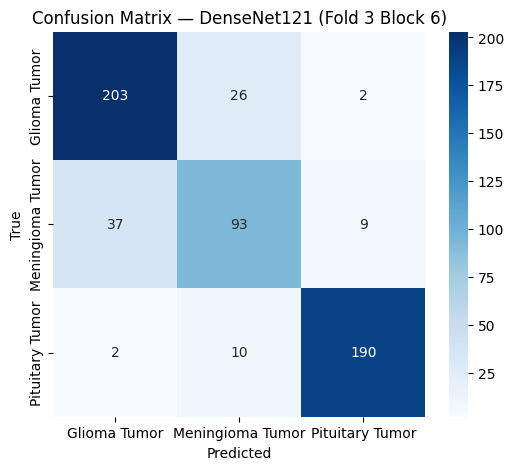

Fold: 3 block 5

Fold: 3 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 2,163,203
Non-trainable params: 4,793,728
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.1801 - accuracy: 0.8186 | val_loss: 0.1485 - val_accuracy: 0.8357
val_accuracy improved from 0.0000 to 0.8357, saving weights...


Epoch 2/50 | loss: 0.1524 - accuracy: 0.8367 | val_loss: 0.1375 - val_accuracy: 0.8531
val_accuracy improved from 0.8357 to 0.8531, saving weights...


Epoch 3/50 | loss: 0.1376 - accuracy: 0.8435 | val_loss: 0.1224 - val_accuracy: 0.8864
val_accuracy improved from 0.8531 to 0.8864, saving weights...


Epoch 4/50 | loss: 0.1268 - accuracy: 0.8636 | val_loss: 0.1244 - val_accuracy: 0.8671
val_accuracy did not improve from 0.8864


...

Epoch 11/50 | loss: 0.0841 - accuracy: 0.9009 | val_loss: 0.0978 - val_accuracy: 0.8969
val_accuracy did not improve from 0.9021


Epoch 12/50 | loss: 0.0853 - accuracy: 0.9005 | val_loss: 0.0979 - val_accuracy: 0.8969
val_accuracy did not improve from 0.9021


Epoch 13/50 | loss: 0.0800 - accuracy: 0.9089 | val_loss: 0.0978 - val_accuracy: 0.8934
val_accuracy did not improve from 0.9021


Epoch 14/50 | loss: 0.0795 - accuracy: 0.9077 | val_loss: 0.0949 - val_accuracy: 0.8969
val_accuracy did not improve from 0.9021


Epoch 15/50 | loss: 0.0766 - accuracy: 0.9121 | val_loss: 0.0913 - val_accuracy: 0.8986
val_accuracy did not improve from 0.9021
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 5)  0.099524  0.902098

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.87      0.92      0.90       231
Meningioma Tumor       0.84      0.74      0.79       139
 Pituitary Tumor       0.97      0.99      0.98       202

        accuracy                           0.90       572
       macro avg       0.90      0.88      0.89       572
    weighted avg       0.90      0.90      0.90       572



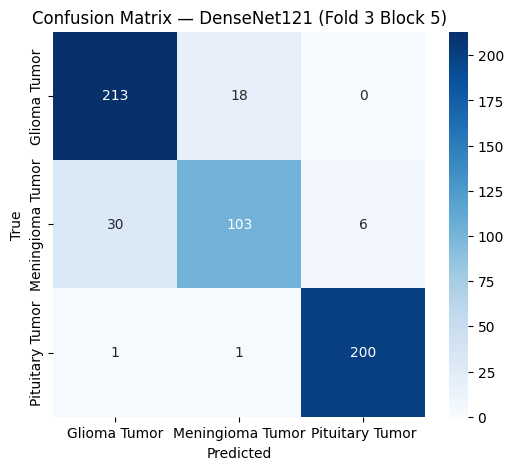

Fold: 3 block 4

Fold: 3 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 5,527,299
Non-trainable params: 1,429,632
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0879 - accuracy: 0.8925 | val_loss: 0.0918 - val_accuracy: 0.8951
val_accuracy improved from 0.0000 to 0.8951, saving weights...


Epoch 2/50 | loss: 0.0753 - accuracy: 0.9121 | val_loss: 0.0919 - val_accuracy: 0.8916
val_accuracy did not improve from 0.8951


Epoch 3/50 | loss: 0.0662 - accuracy: 0.9181 | val_loss: 0.0865 - val_accuracy: 0.9021
val_accuracy improved from 0.8951 to 0.9021, saving weights...


Epoch 4/50 | loss: 0.0571 - accuracy: 0.9306 | val_loss: 0.0837 - val_accuracy: 0.8951
val_accuracy did not improve from 0.9021


...

Epoch 14/50 | loss: 0.0232 - accuracy: 0.9727 | val_loss: 0.0751 - val_accuracy: 0.9266
val_accuracy did not improve from 0.9318


Epoch 15/50 | loss: 0.0207 - accuracy: 0.9731 | val_loss: 0.0945 - val_accuracy: 0.9091
val_accuracy did not improve from 0.9318


Epoch 16/50 | loss: 0.0195 - accuracy: 0.9759 | val_loss: 0.0809 - val_accuracy: 0.9196
val_accuracy did not improve from 0.9318


Epoch 17/50 | loss: 0.0157 - accuracy: 0.9827 | val_loss: 0.0831 - val_accuracy: 0.9213
val_accuracy did not improve from 0.9318


Epoch 18/50 | loss: 0.0165 - accuracy: 0.9779 | val_loss: 0.0773 - val_accuracy: 0.9301
val_accuracy did not improve from 0.9318
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 4)  0.076996  0.931818

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.92      0.93       231
Meningioma Tumor       0.86      0.86      0.86       139
 Pituitary Tumor       0.98      1.00      0.99       202

        accuracy                           0.93       572
       macro avg       0.92      0.92      0.92       572
    weighted avg       0.93      0.93      0.93       572



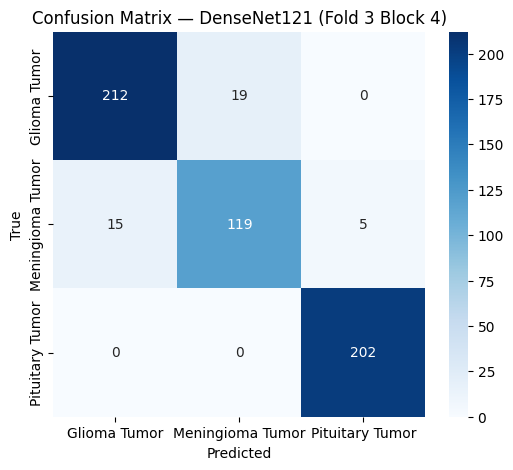

Fold: 3 block 3

Fold: 3 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,579,075
Non-trainable params: 377,856
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward

Epoch 1/50 | loss: 0.0319 - accuracy: 0.9631 | val_loss: 0.0793 - val_accuracy: 0.9213
val_accuracy improved from 0.0000 to 0.9213, saving weights...


Epoch 2/50 | loss: 0.0232 - accuracy: 0.9703 | val_loss: 0.0820 - val_accuracy: 0.9091
val_accuracy did not improve from 0.9213


Epoch 3/50 | loss: 0.0267 - accuracy: 0.9659 | val_loss: 0.0996 - val_accuracy: 0.9161
val_accuracy did not improve from 0.9213


Epoch 4/50 | loss: 0.0193 - accuracy: 0.9807 | val_loss: 0.0853 - val_accuracy: 0.9108
val_accuracy did not improve from 0.9213


...

Epoch 8/50 | loss: 0.0120 - accuracy: 0.9860 | val_loss: 0.0882 - val_accuracy: 0.9248
val_accuracy did not improve from 0.9283


Epoch 9/50 | loss: 0.0134 - accuracy: 0.9843 | val_loss: 0.0819 - val_accuracy: 0.9248
val_accuracy did not improve from 0.9283


Epoch 10/50 | loss: 0.0137 - accuracy: 0.9856 | val_loss: 0.0927 - val_accuracy: 0.9231
val_accuracy did not improve from 0.9283


Epoch 11/50 | loss: 0.0090 - accuracy: 0.9916 | val_loss: 0.0950 - val_accuracy: 0.9196
val_accuracy did not improve from 0.9283


Epoch 12/50 | loss: 0.0117 - accuracy: 0.9920 | val_loss: 0.0898 - val_accuracy: 0.9248
val_accuracy did not improve from 0.9283
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 3)  0.082068  0.928322

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.88      0.92       231
Meningioma Tumor       0.82      0.91      0.86       139
 Pituitary Tumor       0.99      1.00      0.99       202

        accuracy                           0.93       572
       macro avg       0.92      0.93      0.92       572
    weighted avg       0.93      0.93      0.93       572



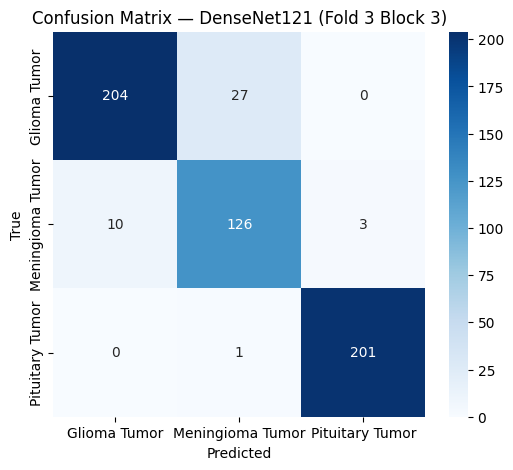

Fold: 3 block 2

Fold: 3 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,947,395
Non-trainable params: 9,536
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0205 - accuracy: 0.9727 | val_loss: 0.0771 - val_accuracy: 0.9143
val_accuracy improved from 0.0000 to 0.9143, saving weights...


Epoch 2/50 | loss: 0.0226 - accuracy: 0.9731 | val_loss: 0.1003 - val_accuracy: 0.9213
val_accuracy improved from 0.9143 to 0.9213, saving weights...


Epoch 3/50 | loss: 0.0151 - accuracy: 0.9807 | val_loss: 0.1044 - val_accuracy: 0.9143
val_accuracy did not improve from 0.9213


Epoch 4/50 | loss: 0.0164 - accuracy: 0.9795 | val_loss: 0.0833 - val_accuracy: 0.9318
val_accuracy improved from 0.9213 to 0.9318, saving weights...


...

Epoch 6/50 | loss: 0.0091 - accuracy: 0.9896 | val_loss: 0.0910 - val_accuracy: 0.9266
val_accuracy did not improve from 0.9318


Epoch 7/50 | loss: 0.0078 - accuracy: 0.9912 | val_loss: 0.0793 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9318


Epoch 8/50 | loss: 0.0069 - accuracy: 0.9916 | val_loss: 0.0951 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9318


Epoch 9/50 | loss: 0.0068 - accuracy: 0.9920 | val_loss: 0.0824 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9318


Epoch 10/50 | loss: 0.0065 - accuracy: 0.9916 | val_loss: 0.0907 - val_accuracy: 0.9301
val_accuracy did not improve from 0.9318
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 2)  0.083329  0.931818

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.92      0.93       231
Meningioma Tumor       0.86      0.86      0.86       139
 Pituitary Tumor       0.97      1.00      0.98       202

        accuracy                           0.93       572
       macro avg       0.92      0.92      0.92       572
    weighted avg       0.93      0.93      0.93       572



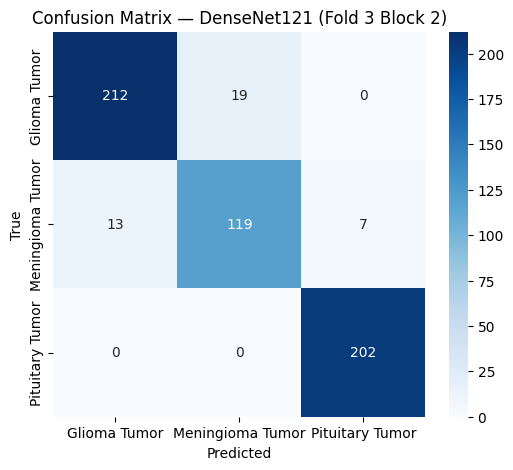

Fold: 3 block 1

Fold: 3 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,956,931
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward pass size (

Epoch 1/50 | loss: 0.0201 - accuracy: 0.9751 | val_loss: 0.0870 - val_accuracy: 0.9336
val_accuracy improved from 0.0000 to 0.9336, saving weights...


Epoch 2/50 | loss: 0.0125 - accuracy: 0.9839 | val_loss: 0.1215 - val_accuracy: 0.9126
val_accuracy did not improve from 0.9336


Epoch 3/50 | loss: 0.0122 - accuracy: 0.9835 | val_loss: 0.1340 - val_accuracy: 0.9073
val_accuracy did not improve from 0.9336


Epoch 4/50 | loss: 0.0180 - accuracy: 0.9791 | val_loss: 0.1455 - val_accuracy: 0.8934
val_accuracy did not improve from 0.9336


...

Epoch 8/50 | loss: 0.0057 - accuracy: 0.9932 | val_loss: 0.0806 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9371


Epoch 9/50 | loss: 0.0040 - accuracy: 0.9972 | val_loss: 0.0936 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9371


Epoch 10/50 | loss: 0.0034 - accuracy: 0.9980 | val_loss: 0.1037 - val_accuracy: 0.9301
val_accuracy did not improve from 0.9371


Epoch 11/50 | loss: 0.0047 - accuracy: 0.9928 | val_loss: 0.0964 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9371


Epoch 12/50 | loss: 0.0033 - accuracy: 0.9964 | val_loss: 0.0925 - val_accuracy: 0.9371
val_accuracy did not improve from 0.9371
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 1)  0.079852  0.937063

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.91      0.93       231
Meningioma Tumor       0.86      0.89      0.87       139
 Pituitary Tumor       0.97      1.00      0.99       202

        accuracy                           0.94       572
       macro avg       0.93      0.93      0.93       572
    weighted avg       0.94      0.94      0.94       572



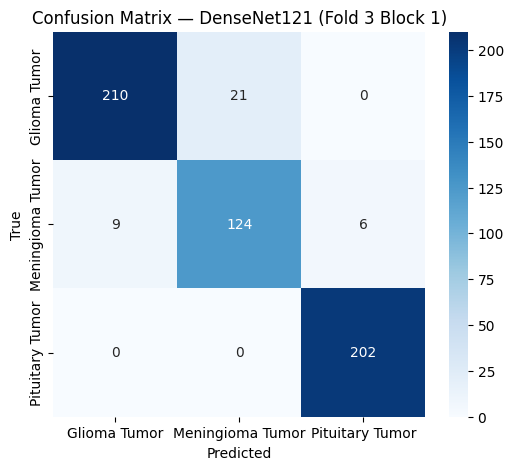

Fold: 4 block 6

Fold: 4 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     (6,953,856)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 3,075
Non-trainable params: 6,953,856
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward pas

Epoch 1/50 | loss: 0.6054 - accuracy: 0.3740 | val_loss: 0.4186 - val_accuracy: 0.4968
val_accuracy improved from 0.0000 to 0.4968, saving weights to /kaggle/working/DenseNet121_block_6_fold_4.pth


Epoch 2/50 | loss: 0.4730 - accuracy: 0.4807 | val_loss: 0.3497 - val_accuracy: 0.6449
val_accuracy improved from 0.4968 to 0.6449, saving weights to /kaggle/working/DenseNet121_block_6_fold_4.pth


Epoch 3/50 | loss: 0.3967 - accuracy: 0.5788 | val_loss: 0.3037 - val_accuracy: 0.6943
val_accuracy improved from 0.6449 to 0.6943, saving weights to /kaggle/working/DenseNet121_block_6_fold_4.pth


Epoch 4/50 | loss: 0.3452 - accuracy: 0.6178 | val_loss: 0.2671 - val_accuracy: 0.7500
val_accuracy improved from 0.6943 to 0.7500, saving weights to /kaggle/working/DenseNet121_block_6_fold_4.pth


...

Epoch 21/50 | loss: 0.1800 - accuracy: 0.8050 | val_loss: 0.1387 - val_accuracy: 0.8710
val_accuracy did not improve from 0.8774


Epoch 22/50 | loss: 0.1728 - accuracy: 0.8173 | val_loss: 0.1367 - val_accuracy: 0.8774
val_accuracy did not improve from 0.8774


Epoch 23/50 | loss: 0.1819 - accuracy: 0.7976 | val_loss: 0.1388 - val_accuracy: 0.8678
val_accuracy did not improve from 0.8774


Epoch 24/50 | loss: 0.1758 - accuracy: 0.8075 | val_loss: 0.1447 - val_accuracy: 0.8535
val_accuracy did not improve from 0.8774


Epoch 25/50 | loss: 0.1796 - accuracy: 0.8046 | val_loss: 0.1330 - val_accuracy: 0.8742
val_accuracy did not improve from 0.8774
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  DenseNet121  0.140667  0.877389
                  precision    recall  f1-score   support

    Glioma Tumor       0.87      0.98      0.92       325
Meningioma Tumor       0.88      0.49      0.63       124
 Pituitary Tumor       0.89      0.96      0.92       179

        accuracy                           0.88       628
       macro avg       0.88      0.81      0.83       628
    weighted avg       0.88      0.88      0.86       628



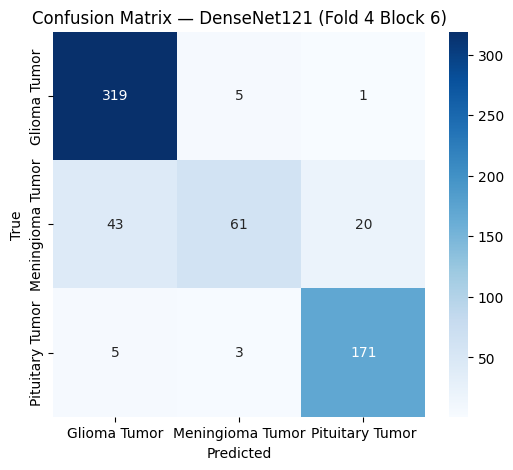

Fold: 4 block 5

Fold: 4 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 2,163,203
Non-trainable params: 4,793,728
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.1753 - accuracy: 0.8099 | val_loss: 0.1342 - val_accuracy: 0.8662
val_accuracy improved from 0.0000 to 0.8662, saving weights...


Epoch 2/50 | loss: 0.1584 - accuracy: 0.8222 | val_loss: 0.1185 - val_accuracy: 0.8646
val_accuracy did not improve from 0.8662


Epoch 3/50 | loss: 0.1423 - accuracy: 0.8415 | val_loss: 0.1099 - val_accuracy: 0.8854
val_accuracy improved from 0.8662 to 0.8854, saving weights...


Epoch 4/50 | loss: 0.1285 - accuracy: 0.8539 | val_loss: 0.1007 - val_accuracy: 0.8885
val_accuracy improved from 0.8854 to 0.8885, saving weights...


...

Epoch 30/50 | loss: 0.0613 - accuracy: 0.9273 | val_loss: 0.0624 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9395


Epoch 31/50 | loss: 0.0566 - accuracy: 0.9290 | val_loss: 0.0616 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9395


Epoch 32/50 | loss: 0.0527 - accuracy: 0.9331 | val_loss: 0.0610 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9395


Epoch 33/50 | loss: 0.0547 - accuracy: 0.9302 | val_loss: 0.0607 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9395


Epoch 34/50 | loss: 0.0577 - accuracy: 0.9323 | val_loss: 0.0609 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9395
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 5)  0.061698   0.93949

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.98      0.96       325
Meningioma Tumor       0.87      0.83      0.85       124
 Pituitary Tumor       0.98      0.94      0.96       179

        accuracy                           0.94       628
       macro avg       0.93      0.92      0.92       628
    weighted avg       0.94      0.94      0.94       628



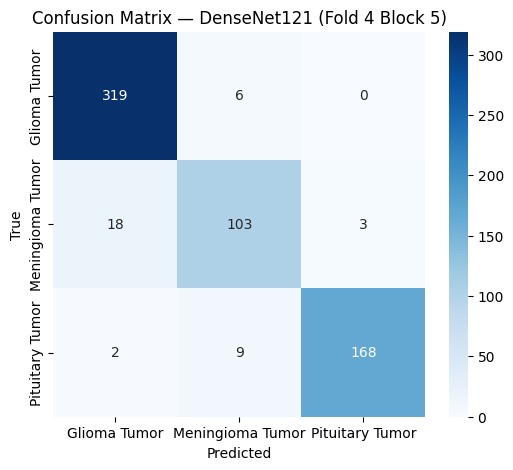

Fold: 4 block 4

Fold: 4 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 5,527,299
Non-trainable params: 1,429,632
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0615 - accuracy: 0.9278 | val_loss: 0.0548 - val_accuracy: 0.9252
val_accuracy improved from 0.0000 to 0.9252, saving weights...


Epoch 2/50 | loss: 0.0501 - accuracy: 0.9339 | val_loss: 0.0564 - val_accuracy: 0.9315
val_accuracy improved from 0.9252 to 0.9315, saving weights...


Epoch 3/50 | loss: 0.0507 - accuracy: 0.9314 | val_loss: 0.0502 - val_accuracy: 0.9506
val_accuracy improved from 0.9315 to 0.9506, saving weights...


Epoch 4/50 | loss: 0.0461 - accuracy: 0.9442 | val_loss: 0.0565 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9506


...

Epoch 20/50 | loss: 0.0162 - accuracy: 0.9799 | val_loss: 0.0457 - val_accuracy: 0.9554
val_accuracy did not improve from 0.9570


Epoch 21/50 | loss: 0.0129 - accuracy: 0.9873 | val_loss: 0.0453 - val_accuracy: 0.9570
val_accuracy did not improve from 0.9570


Epoch 22/50 | loss: 0.0132 - accuracy: 0.9856 | val_loss: 0.0451 - val_accuracy: 0.9570
val_accuracy did not improve from 0.9570


Epoch 23/50 | loss: 0.0143 - accuracy: 0.9844 | val_loss: 0.0448 - val_accuracy: 0.9570
val_accuracy did not improve from 0.9570


Epoch 24/50 | loss: 0.0181 - accuracy: 0.9758 | val_loss: 0.0444 - val_accuracy: 0.9570
val_accuracy did not improve from 0.9570
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 4)  0.044047  0.957006

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.98      0.98       325
Meningioma Tumor       0.88      0.91      0.90       124
 Pituitary Tumor       0.97      0.96      0.96       179

        accuracy                           0.96       628
       macro avg       0.94      0.95      0.95       628
    weighted avg       0.96      0.96      0.96       628



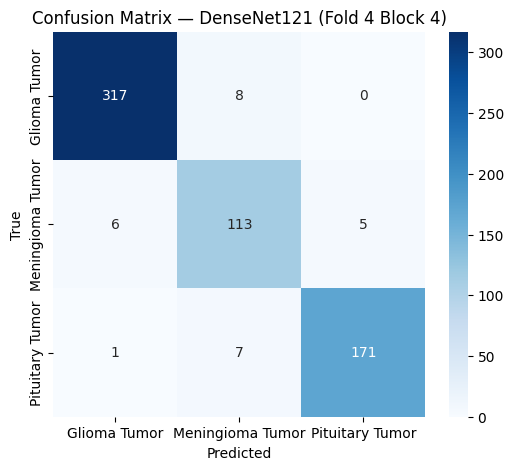

Fold: 4 block 3

Fold: 4 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,579,075
Non-trainable params: 377,856
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward

Epoch 1/50 | loss: 0.0248 - accuracy: 0.9709 | val_loss: 0.0421 - val_accuracy: 0.9554
val_accuracy improved from 0.0000 to 0.9554, saving weights...


Epoch 2/50 | loss: 0.0228 - accuracy: 0.9692 | val_loss: 0.0443 - val_accuracy: 0.9506
val_accuracy did not improve from 0.9554


Epoch 3/50 | loss: 0.0164 - accuracy: 0.9795 | val_loss: 0.0456 - val_accuracy: 0.9602
val_accuracy improved from 0.9554 to 0.9602, saving weights...


Epoch 4/50 | loss: 0.0162 - accuracy: 0.9766 | val_loss: 0.0391 - val_accuracy: 0.9586
val_accuracy did not improve from 0.9602


Epoch 5/50 | loss: 0.0142 - accuracy: 0.9799 | val_loss: 0.0398 - val_accuracy: 0.9554
val_accuracy did not improve from 0.9602


Epoch 6/50 | loss: 0.0143 - accuracy: 0.9832 | val_loss: 0.0407 - val_accuracy: 0.9538
val_accuracy did not improve from 0.9602


Epoch 7/50 | loss: 0.0113 - accuracy: 0.9828 | val_loss: 0.0408 - val_accuracy: 0.9554
val_accuracy did not improve from 0.9602


Epoch 8/50 | loss: 0.0145 - accuracy: 0.9828 | val_loss: 0.0459 - val_accuracy: 0.9506
val_accuracy did not improve from 0.9602


Epoch 9/50 | loss: 0.0096 - accuracy: 0.9893 | val_loss: 0.0502 - val_accuracy: 0.9570
val_accuracy did not improve from 0.9602
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 3)  0.045616  0.960191

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.97      0.98       325
Meningioma Tumor       0.87      0.95      0.91       124
 Pituitary Tumor       0.98      0.96      0.97       179

        accuracy                           0.96       628
       macro avg       0.95      0.96      0.95       628
    weighted avg       0.96      0.96      0.96       628



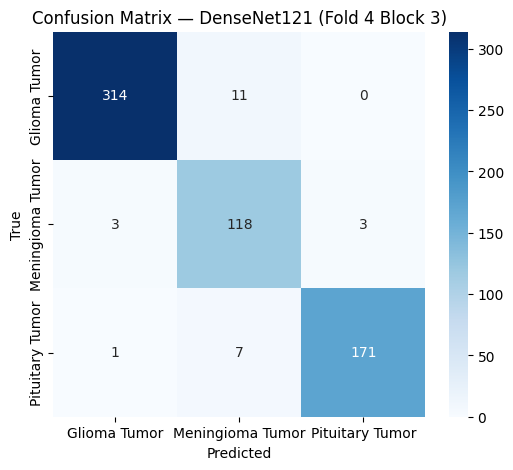

Fold: 4 block 2

Fold: 4 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,947,395
Non-trainable params: 9,536
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0261 - accuracy: 0.9676 | val_loss: 0.0404 - val_accuracy: 0.9506
val_accuracy improved from 0.0000 to 0.9506, saving weights...


Epoch 2/50 | loss: 0.0139 - accuracy: 0.9787 | val_loss: 0.0474 - val_accuracy: 0.9586
val_accuracy improved from 0.9506 to 0.9586, saving weights...


Epoch 3/50 | loss: 0.0174 - accuracy: 0.9807 | val_loss: 0.0458 - val_accuracy: 0.9570
val_accuracy did not improve from 0.9586


Epoch 4/50 | loss: 0.0158 - accuracy: 0.9856 | val_loss: 0.0410 - val_accuracy: 0.9554
val_accuracy did not improve from 0.9586


...

Epoch 12/50 | loss: 0.0061 - accuracy: 0.9918 | val_loss: 0.0394 - val_accuracy: 0.9618
val_accuracy did not improve from 0.9650


Epoch 13/50 | loss: 0.0042 - accuracy: 0.9951 | val_loss: 0.0394 - val_accuracy: 0.9602
val_accuracy did not improve from 0.9650


Epoch 14/50 | loss: 0.0064 - accuracy: 0.9914 | val_loss: 0.0410 - val_accuracy: 0.9618
val_accuracy did not improve from 0.9650


Epoch 15/50 | loss: 0.0049 - accuracy: 0.9955 | val_loss: 0.0405 - val_accuracy: 0.9602
val_accuracy did not improve from 0.9650


Epoch 16/50 | loss: 0.0050 - accuracy: 0.9955 | val_loss: 0.0403 - val_accuracy: 0.9602
val_accuracy did not improve from 0.9650
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model     Loss  Accuracy
0  DenseNet121 (Block 2)  0.04077  0.964968

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.98      0.98       325
Meningioma Tumor       0.90      0.93      0.91       124
 Pituitary Tumor       0.97      0.97      0.97       179

        accuracy                           0.96       628
       macro avg       0.95      0.96      0.95       628
    weighted avg       0.97      0.96      0.97       628



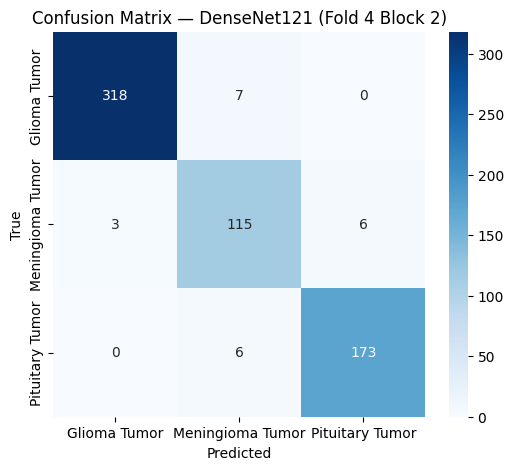

Fold: 4 block 1

Fold: 4 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,956,931
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward pass size (

Epoch 1/50 | loss: 0.0137 - accuracy: 0.9844 | val_loss: 0.0496 - val_accuracy: 0.9475
val_accuracy improved from 0.0000 to 0.9475, saving weights...


Epoch 2/50 | loss: 0.0136 - accuracy: 0.9848 | val_loss: 0.0421 - val_accuracy: 0.9618
val_accuracy improved from 0.9475 to 0.9618, saving weights...


Epoch 3/50 | loss: 0.0150 - accuracy: 0.9803 | val_loss: 0.0409 - val_accuracy: 0.9586
val_accuracy did not improve from 0.9618


Epoch 4/50 | loss: 0.0094 - accuracy: 0.9901 | val_loss: 0.0429 - val_accuracy: 0.9586
val_accuracy did not improve from 0.9618


Epoch 5/50 | loss: 0.0071 - accuracy: 0.9926 | val_loss: 0.0596 - val_accuracy: 0.9443
val_accuracy did not improve from 0.9618


Epoch 6/50 | loss: 0.0071 - accuracy: 0.9901 | val_loss: 0.0442 - val_accuracy: 0.9602
val_accuracy did not improve from 0.9618


Epoch 7/50 | loss: 0.0095 - accuracy: 0.9885 | val_loss: 0.0390 - val_accuracy: 0.9602
val_accuracy did not improve from 0.9618


Epoch 8/50 | loss: 0.0087 - accuracy: 0.9893 | val_loss: 0.0545 - val_accuracy: 0.9538
val_accuracy did not improve from 0.9618
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 1)  0.042094  0.961783

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.99      0.98       325
Meningioma Tumor       0.92      0.89      0.90       124
 Pituitary Tumor       0.96      0.97      0.96       179

        accuracy                           0.96       628
       macro avg       0.95      0.95      0.95       628
    weighted avg       0.96      0.96      0.96       628



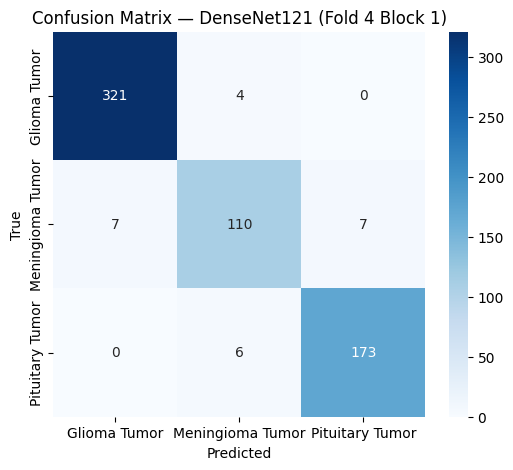

Fold: 5 block 6

Fold: 5 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     (6,953,856)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 3,075
Non-trainable params: 6,953,856
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward pas

Epoch 1/50 | loss: 0.5257 - accuracy: 0.4283 | val_loss: 0.4745 - val_accuracy: 0.5039
val_accuracy improved from 0.0000 to 0.5039, saving weights to /kaggle/working/DenseNet121_block_6_fold_5.pth


Epoch 2/50 | loss: 0.4259 - accuracy: 0.5374 | val_loss: 0.3978 - val_accuracy: 0.6003
val_accuracy improved from 0.5039 to 0.6003, saving weights to /kaggle/working/DenseNet121_block_6_fold_5.pth


Epoch 3/50 | loss: 0.3563 - accuracy: 0.6208 | val_loss: 0.3592 - val_accuracy: 0.6547
val_accuracy improved from 0.6003 to 0.6547, saving weights to /kaggle/working/DenseNet121_block_6_fold_5.pth


Epoch 4/50 | loss: 0.3160 - accuracy: 0.6683 | val_loss: 0.3496 - val_accuracy: 0.6827
val_accuracy improved from 0.6547 to 0.6827, saving weights to /kaggle/working/DenseNet121_block_6_fold_5.pth


...

Epoch 31/50 | loss: 0.1486 - accuracy: 0.8331 | val_loss: 0.1910 - val_accuracy: 0.7838
val_accuracy did not improve from 0.8025


Epoch 32/50 | loss: 0.1451 - accuracy: 0.8410 | val_loss: 0.2063 - val_accuracy: 0.7807
val_accuracy did not improve from 0.8025


Epoch 33/50 | loss: 0.1403 - accuracy: 0.8463 | val_loss: 0.1895 - val_accuracy: 0.7869
val_accuracy did not improve from 0.8025


Epoch 34/50 | loss: 0.1407 - accuracy: 0.8501 | val_loss: 0.1914 - val_accuracy: 0.7854
val_accuracy did not improve from 0.8025


Epoch 35/50 | loss: 0.1341 - accuracy: 0.8583 | val_loss: 0.1883 - val_accuracy: 0.7900
val_accuracy did not improve from 0.8025
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  DenseNet121  0.191353  0.802488
                  precision    recall  f1-score   support

    Glioma Tumor       0.83      0.88      0.86       287
Meningioma Tumor       0.70      0.51      0.59       166
 Pituitary Tumor       0.82      0.94      0.88       190

        accuracy                           0.80       643
       macro avg       0.78      0.78      0.77       643
    weighted avg       0.79      0.80      0.79       643



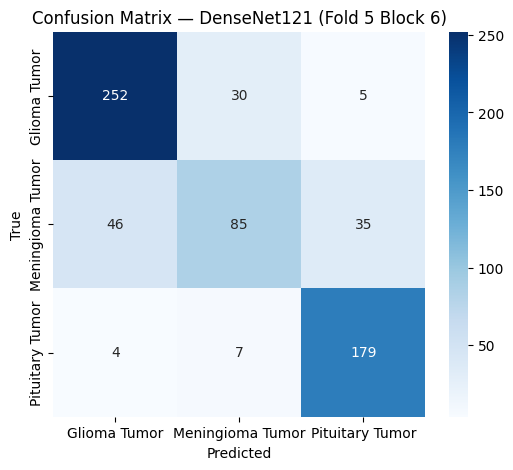

Fold: 5 block 5

Fold: 5 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 2,163,203
Non-trainable params: 4,793,728
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.1318 - accuracy: 0.8587 | val_loss: 0.1961 - val_accuracy: 0.7698
val_accuracy improved from 0.0000 to 0.7698, saving weights...


Epoch 2/50 | loss: 0.1192 - accuracy: 0.8682 | val_loss: 0.1736 - val_accuracy: 0.7978
val_accuracy improved from 0.7698 to 0.7978, saving weights...


Epoch 3/50 | loss: 0.1115 - accuracy: 0.8744 | val_loss: 0.1610 - val_accuracy: 0.8149
val_accuracy improved from 0.7978 to 0.8149, saving weights...


Epoch 4/50 | loss: 0.1063 - accuracy: 0.8753 | val_loss: 0.1709 - val_accuracy: 0.8180
val_accuracy improved from 0.8149 to 0.8180, saving weights...


...

Epoch 20/50 | loss: 0.0547 - accuracy: 0.9285 | val_loss: 0.1409 - val_accuracy: 0.8491
val_accuracy did not improve from 0.8538


Epoch 21/50 | loss: 0.0537 - accuracy: 0.9318 | val_loss: 0.1427 - val_accuracy: 0.8491
val_accuracy did not improve from 0.8538


Epoch 22/50 | loss: 0.0476 - accuracy: 0.9380 | val_loss: 0.1443 - val_accuracy: 0.8523
val_accuracy did not improve from 0.8538


Epoch 23/50 | loss: 0.0516 - accuracy: 0.9339 | val_loss: 0.1489 - val_accuracy: 0.8476
val_accuracy did not improve from 0.8538


Epoch 24/50 | loss: 0.0517 - accuracy: 0.9343 | val_loss: 0.1434 - val_accuracy: 0.8523
val_accuracy did not improve from 0.8538
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 5)  0.144075   0.85381

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.86      0.91       287
Meningioma Tumor       0.70      0.78      0.74       166
 Pituitary Tumor       0.86      0.92      0.89       190

        accuracy                           0.85       643
       macro avg       0.84      0.85      0.84       643
    weighted avg       0.86      0.85      0.86       643



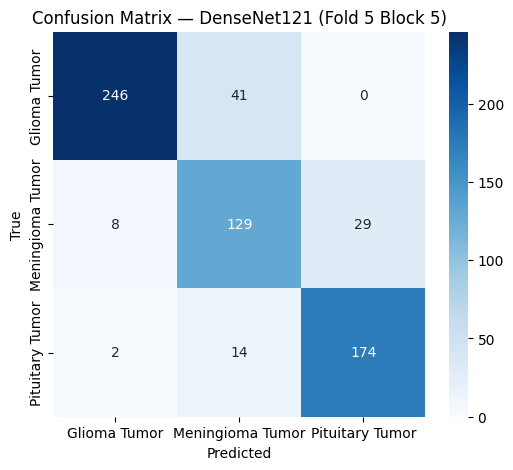

Fold: 5 block 4

Fold: 5 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 5,527,299
Non-trainable params: 1,429,632
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0701 - accuracy: 0.9170 | val_loss: 0.1419 - val_accuracy: 0.8600
val_accuracy improved from 0.0000 to 0.8600, saving weights...


Epoch 2/50 | loss: 0.0557 - accuracy: 0.9335 | val_loss: 0.1489 - val_accuracy: 0.8538
val_accuracy did not improve from 0.8600


Epoch 3/50 | loss: 0.0475 - accuracy: 0.9430 | val_loss: 0.1357 - val_accuracy: 0.8740
val_accuracy improved from 0.8600 to 0.8740, saving weights...


Epoch 4/50 | loss: 0.0456 - accuracy: 0.9376 | val_loss: 0.1363 - val_accuracy: 0.8740
val_accuracy did not improve from 0.8740


...

Epoch 13/50 | loss: 0.0263 - accuracy: 0.9645 | val_loss: 0.1355 - val_accuracy: 0.8880
val_accuracy did not improve from 0.8927


Epoch 14/50 | loss: 0.0263 - accuracy: 0.9678 | val_loss: 0.1372 - val_accuracy: 0.8896
val_accuracy did not improve from 0.8927


Epoch 15/50 | loss: 0.0199 - accuracy: 0.9719 | val_loss: 0.1452 - val_accuracy: 0.8849
val_accuracy did not improve from 0.8927


Epoch 16/50 | loss: 0.0231 - accuracy: 0.9703 | val_loss: 0.1402 - val_accuracy: 0.8865
val_accuracy did not improve from 0.8927


Epoch 17/50 | loss: 0.0190 - accuracy: 0.9748 | val_loss: 0.1438 - val_accuracy: 0.8880
val_accuracy did not improve from 0.8927
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 4)  0.130969  0.892691

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.92      0.94       287
Meningioma Tumor       0.80      0.79      0.79       166
 Pituitary Tumor       0.88      0.94      0.91       190

        accuracy                           0.89       643
       macro avg       0.88      0.88      0.88       643
    weighted avg       0.89      0.89      0.89       643



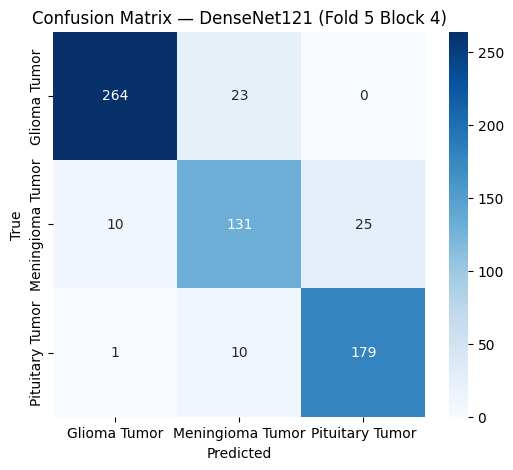

Fold: 5 block 3

Fold: 5 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,579,075
Non-trainable params: 377,856
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward

Epoch 1/50 | loss: 0.0320 - accuracy: 0.9603 | val_loss: 0.1469 - val_accuracy: 0.9005
val_accuracy improved from 0.0000 to 0.9005, saving weights...


Epoch 2/50 | loss: 0.0270 - accuracy: 0.9624 | val_loss: 0.1671 - val_accuracy: 0.8911
val_accuracy did not improve from 0.9005


Epoch 3/50 | loss: 0.0278 - accuracy: 0.9698 | val_loss: 0.1101 - val_accuracy: 0.8927
val_accuracy did not improve from 0.9005


Epoch 4/50 | loss: 0.0239 - accuracy: 0.9703 | val_loss: 0.1281 - val_accuracy: 0.8927
val_accuracy did not improve from 0.9005


...

Epoch 16/50 | loss: 0.0071 - accuracy: 0.9917 | val_loss: 0.1369 - val_accuracy: 0.9098
val_accuracy did not improve from 0.9129


Epoch 17/50 | loss: 0.0088 - accuracy: 0.9905 | val_loss: 0.1397 - val_accuracy: 0.9067
val_accuracy did not improve from 0.9129


Epoch 18/50 | loss: 0.0075 - accuracy: 0.9905 | val_loss: 0.1386 - val_accuracy: 0.9082
val_accuracy did not improve from 0.9129


Epoch 19/50 | loss: 0.0098 - accuracy: 0.9872 | val_loss: 0.1391 - val_accuracy: 0.9098
val_accuracy did not improve from 0.9129


Epoch 20/50 | loss: 0.0088 - accuracy: 0.9897 | val_loss: 0.1398 - val_accuracy: 0.9098
val_accuracy did not improve from 0.9129
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 3)  0.142066  0.912908

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.92      0.95       287
Meningioma Tumor       0.83      0.83      0.83       166
 Pituitary Tumor       0.88      0.97      0.92       190

        accuracy                           0.91       643
       macro avg       0.90      0.91      0.90       643
    weighted avg       0.92      0.91      0.91       643



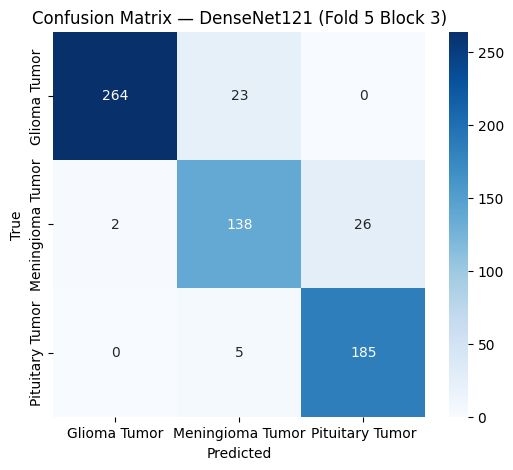

Fold: 5 block 2

Fold: 5 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,947,395
Non-trainable params: 9,536
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0180 - accuracy: 0.9781 | val_loss: 0.1165 - val_accuracy: 0.9020
val_accuracy improved from 0.0000 to 0.9020, saving weights...


Epoch 2/50 | loss: 0.0190 - accuracy: 0.9777 | val_loss: 0.1308 - val_accuracy: 0.8849
val_accuracy did not improve from 0.9020


Epoch 3/50 | loss: 0.0127 - accuracy: 0.9793 | val_loss: 0.1780 - val_accuracy: 0.8989
val_accuracy did not improve from 0.9020


Epoch 4/50 | loss: 0.0108 - accuracy: 0.9847 | val_loss: 0.2160 - val_accuracy: 0.8865
val_accuracy did not improve from 0.9020


...

Epoch 11/50 | loss: 0.0046 - accuracy: 0.9963 | val_loss: 0.1387 - val_accuracy: 0.9207
val_accuracy did not improve from 0.9222


Epoch 12/50 | loss: 0.0049 - accuracy: 0.9950 | val_loss: 0.1560 - val_accuracy: 0.9067
val_accuracy did not improve from 0.9222


Epoch 13/50 | loss: 0.0046 - accuracy: 0.9942 | val_loss: 0.1318 - val_accuracy: 0.9207
val_accuracy did not improve from 0.9222


Epoch 14/50 | loss: 0.0036 - accuracy: 0.9959 | val_loss: 0.1374 - val_accuracy: 0.9222
val_accuracy did not improve from 0.9222


Epoch 15/50 | loss: 0.0032 - accuracy: 0.9967 | val_loss: 0.1353 - val_accuracy: 0.9222
val_accuracy did not improve from 0.9222
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 2)  0.122984   0.92224

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.95      0.96       287
Meningioma Tumor       0.87      0.83      0.85       166
 Pituitary Tumor       0.89      0.96      0.93       190

        accuracy                           0.92       643
       macro avg       0.91      0.91      0.91       643
    weighted avg       0.92      0.92      0.92       643



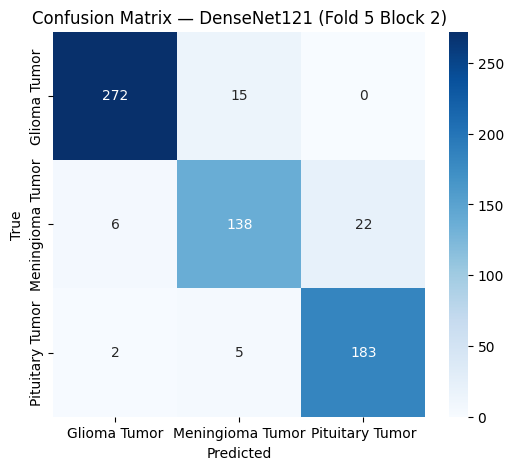

Fold: 5 block 1

Fold: 5 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
DenseNet121 (DenseNet121)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1024, 7, 7]     6,953,856            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                           [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                         [32, 1024]           [32, 3]              3,075                True
Total params: 6,956,931
Trainable params: 6,956,931
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 90.66
Input size (MB): 19.27
Forward/backward pass size (

Epoch 1/50 | loss: 0.0120 - accuracy: 0.9855 | val_loss: 0.1229 - val_accuracy: 0.9020
val_accuracy improved from 0.0000 to 0.9020, saving weights...


Epoch 2/50 | loss: 0.0072 - accuracy: 0.9913 | val_loss: 0.1542 - val_accuracy: 0.9020
val_accuracy did not improve from 0.9020


Epoch 3/50 | loss: 0.0079 - accuracy: 0.9888 | val_loss: 0.1367 - val_accuracy: 0.9269
val_accuracy improved from 0.9020 to 0.9269, saving weights...


Epoch 4/50 | loss: 0.0087 - accuracy: 0.9893 | val_loss: 0.1501 - val_accuracy: 0.9160
val_accuracy did not improve from 0.9269


Epoch 5/50 | loss: 0.0056 - accuracy: 0.9930 | val_loss: 0.1667 - val_accuracy: 0.9145
val_accuracy did not improve from 0.9269


Epoch 6/50 | loss: 0.0037 - accuracy: 0.9946 | val_loss: 0.1508 - val_accuracy: 0.9191
val_accuracy did not improve from 0.9269


Epoch 7/50 | loss: 0.0027 - accuracy: 0.9967 | val_loss: 0.1491 - val_accuracy: 0.9238
val_accuracy did not improve from 0.9269


Epoch 8/50 | loss: 0.0026 - accuracy: 0.9967 | val_loss: 0.1650 - val_accuracy: 0.9129
val_accuracy did not improve from 0.9269


Epoch 9/50 | loss: 0.0019 - accuracy: 0.9983 | val_loss: 0.1505 - val_accuracy: 0.9207
val_accuracy did not improve from 0.9269
Early stopping triggered. Restoring best weights.

Evaluation Results:
                   Model      Loss  Accuracy
0  DenseNet121 (Block 1)  0.136741  0.926905

Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.95      0.97       287
Meningioma Tumor       0.89      0.82      0.86       166
 Pituitary Tumor       0.88      0.98      0.93       190

        accuracy                           0.93       643
       macro avg       0.92      0.92      0.92       643
    weighted avg       0.93      0.93      0.93       643



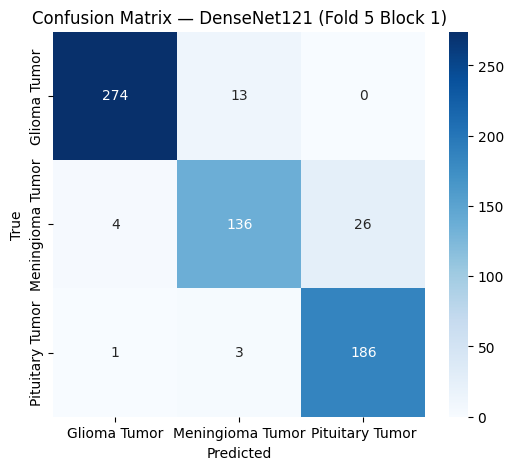

In [18]:
acc_b1, acc_b2, acc_b3, acc_b4, acc_b5, acc_b6 = [], [], [], [], [], []

for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 6')
    train_loader, val_loader = get_data_for_fold(k=fold_k)

    acc_b6.append(test_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k))

    torch.cuda.empty_cache()
    gc.collect()

    for block in range(5, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
        acc_list[block].append(test_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block))

        torch.cuda.empty_cache()
        gc.collect()

    del train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()

In [19]:
ACC_BLOCK = [acc_b6, acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]

for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {6 - _} - block 6: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 6 - block 6: 83.71%
Accuracy unfreeze block 5 - block 6: 88.88%
Accuracy unfreeze block 4 - block 6: 93.37%
Accuracy unfreeze block 3 - block 6: 94.05%
Accuracy unfreeze block 2 - block 6: 94.93%
Accuracy unfreeze block 1 - block 6: 94.91%
